# Step 6 inferh0 lens-model and source visualization


In [1]:
import os
# Force CPU before importing anything that may import JAX. Restart the kernel after changing this cell.
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['JAX_PLATFORM_NAME'] = 'cpu'
os.environ['CUDA_VISIBLE_DEVICES'] = ''
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ.setdefault('HDF5_USE_FILE_LOCKING', 'FALSE')

from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

import arviz as az
import corner
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib import colors
from tqdm.auto import tqdm
import numpy as np
import xarray as xr
from astropy.io import fits

if str(Path.cwd()) not in sys.path:
    sys.path.append(str(Path.cwd()))

from herculens.Coordinates.pixel_grid import PixelGrid
from herculens.Instrument.noise import Noise
from herculens.Instrument.psf import PSF
from herculens.LightModel.light_model import LightModel
from herculens.MassModel import mass_model_base
from herculens.MassModel.mass_model import MassModel
from herculens.PointSourceModel.point_source_model import PointSourceModel
from herculens.Util import model_util
from jax_lensing_profiles.MassModel.Profiles.CuspyNFW_ellipse_kappa import CuspyNFW_3D_fn
from jax_lensing_profiles.MassModel.Profiles.MGE import MGE
from lens_images_extension import LensImageExtension, pixelize_plane as pixelize_plane_single

plt.rcParams['figure.constrained_layout.use'] = True


class CuspyNFWEllipseKappa(MGE):
    def __init__(self):
        super().__init__(
            CuspyNFW_3D_fn,
            'R_s',
            n_gauss=20,
            n_terms=28,
            sigma_start_mult=1 / 200,
            sigma_end_mult=20,
            three_d=True,
        )


mass_model_base.STRING_MAPPING['CUSPY_NFW_ELLIPSE_KAPPA'] = CuspyNFWEllipseKappa




ERROR:2026-05-06 12:18:13,137:jax._src.xla_bridge:473: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/mnt/lustre2/shared_conda/envs/tianli/herculens_tian/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 471, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/mnt/lustre2/shared_conda/envs/tianli/herculens_tian/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/lustre2/shared_conda/envs/tianli/herculens_tian/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This p

In [2]:
suffix = '_ss=2_fullconcen_light_multimass_step6_pantheonsh0es'
run_tag = '20260502_06'
OUTPUT_ROOT = Path('/mnt/lustre/tianli/quasar_hmc')
RUN_OUTPUT_DIR = OUTPUT_ROOT / f'WFI2033{suffix}_{run_tag}'
NC_PATH = RUN_OUTPUT_DIR / f'WFI2033_all{suffix}.nc'

STEP5_SUFFIX = '_ss=2_fullconcen_light_multimass'
STEP5_RUN_TAG = '20260427_14'
STEP5_RESULT_DIR = Path('./result') / f'result{STEP5_SUFFIX}_{STEP5_RUN_TAG}'
STEP5_PRODUCTS_DIR = STEP5_RESULT_DIR / 'data_products'

RAW_DATA_PATH = Path('../../Data/WFI2033/jw01198-o004_t004_nircam_clear-f115w_i2d.fits')
DATA_BKG_SUB_PATH = STEP5_PRODUCTS_DIR / f'data_bkg_sub{STEP5_SUFFIX}.fits'
DATA_SUB_PATH = STEP5_RESULT_DIR / f'data_minus_lens_light_corrected_psf{STEP5_SUFFIX}.fits'
RMS_WITH_PSF_EXTRA_PATH = STEP5_PRODUCTS_DIR / f'rms_with_psf_extra{STEP5_SUFFIX}.fits'
MASK_OUT_PATH = Path('data/mask_out_center_r16.fits')
FIXED_FIVE_GAUSS_PATH = STEP5_RESULT_DIR / f'fixed_five_gaussians_corrected_psf{STEP5_SUFFIX}.npz'

POSTERIOR_VARS = [
    'model_image',
    'pixels_source_grid',
    'psf_kernel_corrected',
    'mass_from_light_amp',
    'kappa_s_halo',
    'gammain_halo',
    'e_halo',
    'Rs_halo',
    'center_halo',
    'gamma_sheer_halo',
    'theta_E_g1',
    'theta_E_g2',
    'kappa_ext',
]

print('NC_PATH =', NC_PATH)
print('DATA_BKG_SUB_PATH =', DATA_BKG_SUB_PATH)
print('DATA_SUB_PATH =', DATA_SUB_PATH)
print('FIXED_FIVE_GAUSS_PATH =', FIXED_FIVE_GAUSS_PATH)


NC_PATH = /mnt/lustre/tianli/quasar_hmc/WFI2033_ss=2_fullconcen_light_multimass_step6_pantheonsh0es_20260502_06/WFI2033_all_ss=2_fullconcen_light_multimass_step6_pantheonsh0es.nc
DATA_BKG_SUB_PATH = result/result_ss=2_fullconcen_light_multimass_20260427_14/data_products/data_bkg_sub_ss=2_fullconcen_light_multimass.fits
DATA_SUB_PATH = result/result_ss=2_fullconcen_light_multimass_20260427_14/data_minus_lens_light_corrected_psf_ss=2_fullconcen_light_multimass.fits
FIXED_FIVE_GAUSS_PATH = result/result_ss=2_fullconcen_light_multimass_20260427_14/fixed_five_gaussians_corrected_psf_ss=2_fullconcen_light_multimass.npz


In [3]:
DIAGNOSTIC_VARS = [
    'm2l_ratio',
    'm2l_ratio_slope',
    'mass_from_light_amp',
    'total_stellar_mass',
    'kappa_s_halo',
    'gammain_halo',
    'e_halo',
    'Rs_halo',
    'center_halo',
    'gamma_sheer_halo',
    'theta_E_g1',
    'theta_E_g2',
    'theta_E_g3',
    'theta_E_g7',
    'ra_ps',
    'dec_ps',
    'log10_amp_ps',
    'omega_m_cosmo',
    'H0_cosmo',
    'kappa_ext',
]

TRACE_VARS = [
    'm2l_ratio',
    'm2l_ratio_slope',
    'total_stellar_mass',
    'kappa_s_halo',
    'gammain_halo',
    'Rs_halo',
    'center_halo',
    'gamma_sheer_halo',
    'theta_E_g1',
    'theta_E_g2',
    'omega_m_cosmo',
    'H0_cosmo',
    'kappa_ext',
]

CORNER_VARS = [
    'm2l_ratio',
    'm2l_ratio_slope',
    'kappa_s_halo',
    'gammain_halo',
    'Rs_halo',
    'theta_E_g1',
    'theta_E_g2',
    'omega_m_cosmo',
    'H0_cosmo',
    'kappa_ext',
]


In [4]:
post = xr.open_dataset(NC_PATH, group='posterior', engine='h5netcdf')[POSTERIOR_VARS]
sample_stats = xr.open_dataset(NC_PATH, group='sample_stats', engine='h5netcdf')[['diverging']]

num_chains = int(post.sizes['chain'])
num_draws = int(post.sizes['draw'])

print('divergences per chain:')
print(np.asarray(sample_stats['diverging'].sum(dim='draw').values, dtype=int))


divergences per chain:
[0 0 0 0 0 4 1 0]


In [5]:
diagnostic_post = xr.open_dataset(NC_PATH, group='posterior', engine='h5netcdf')[DIAGNOSTIC_VARS].load()
# H0_BLIND_TARGET_MEDIAN = 100.0
# H0_blind_offset = H0_BLIND_TARGET_MEDIAN - float(diagnostic_post['H0_cosmo'].median().values)
# diagnostic_post = diagnostic_post.assign(
#     H0_blind=diagnostic_post['H0_cosmo'] + H0_blind_offset,
# )

diagnostic_sample_stats = sample_stats.load()
diagnostic_idata = az.InferenceData(
    posterior=diagnostic_post,
    sample_stats=diagnostic_sample_stats,
)


az.summary(diagnostic_idata, var_names=TRACE_VARS)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
m2l_ratio,2.278,0.556,1.200,3.271,0.046,0.039,164.0,117.0,1.05
m2l_ratio_slope,0.133,0.105,-0.059,0.293,0.010,0.013,164.0,118.0,1.04
total_stellar_mass,2.039,0.396,1.264,2.741,0.033,0.028,162.0,121.0,1.05
kappa_s_halo,0.071,0.044,0.015,0.154,0.005,0.003,82.0,369.0,1.07
gammain_halo,1.287,0.150,1.005,1.546,0.012,0.006,170.0,179.0,1.04
Rs_halo,8.776,5.076,2.049,17.583,0.826,0.227,42.0,180.0,1.14
center_halo[0],0.021,0.006,0.011,0.031,0.000,0.000,166.0,179.0,1.04
center_halo[1],-0.055,0.012,-0.077,-0.034,0.001,0.001,154.0,147.0,1.05
gamma_sheer_halo[0],-0.002,0.003,-0.009,0.004,0.000,0.000,101.0,221.0,1.07
gamma_sheer_halo[1],-0.113,0.006,-0.123,-0.101,0.000,0.000,234.0,234.0,1.04


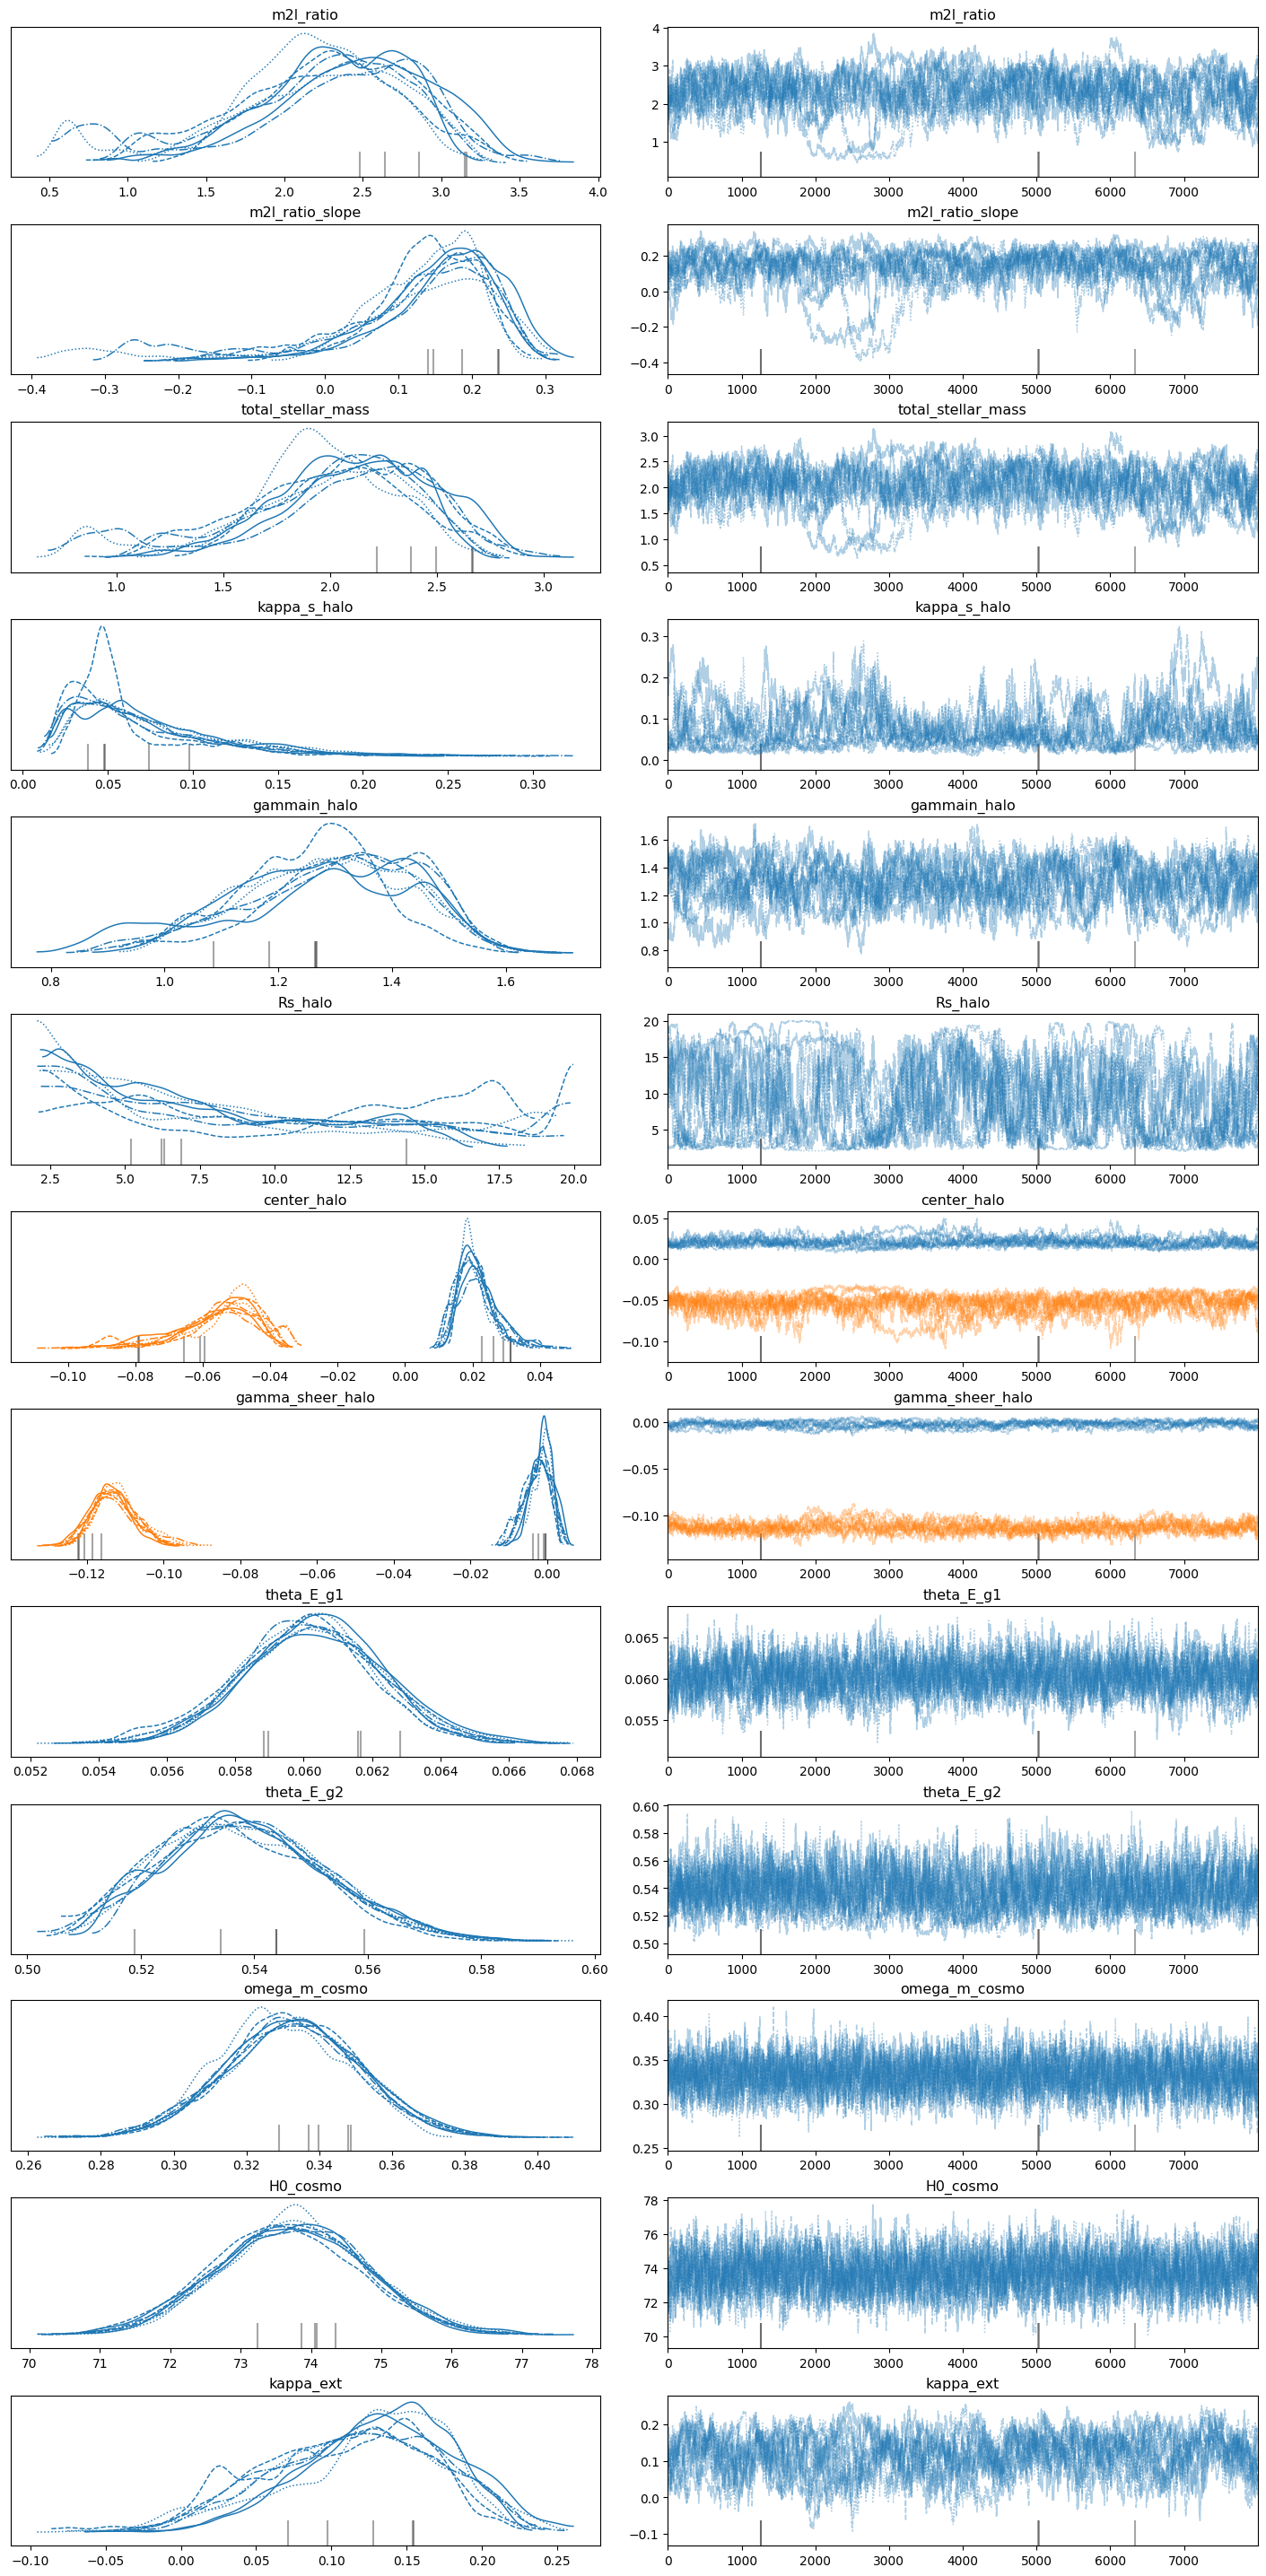

In [6]:
trace_axes = az.plot_trace(
    diagnostic_idata,
    var_names=TRACE_VARS,
    divergences=True,
    figsize=(14, 2.2 * len(TRACE_VARS)),
)
plt.show()


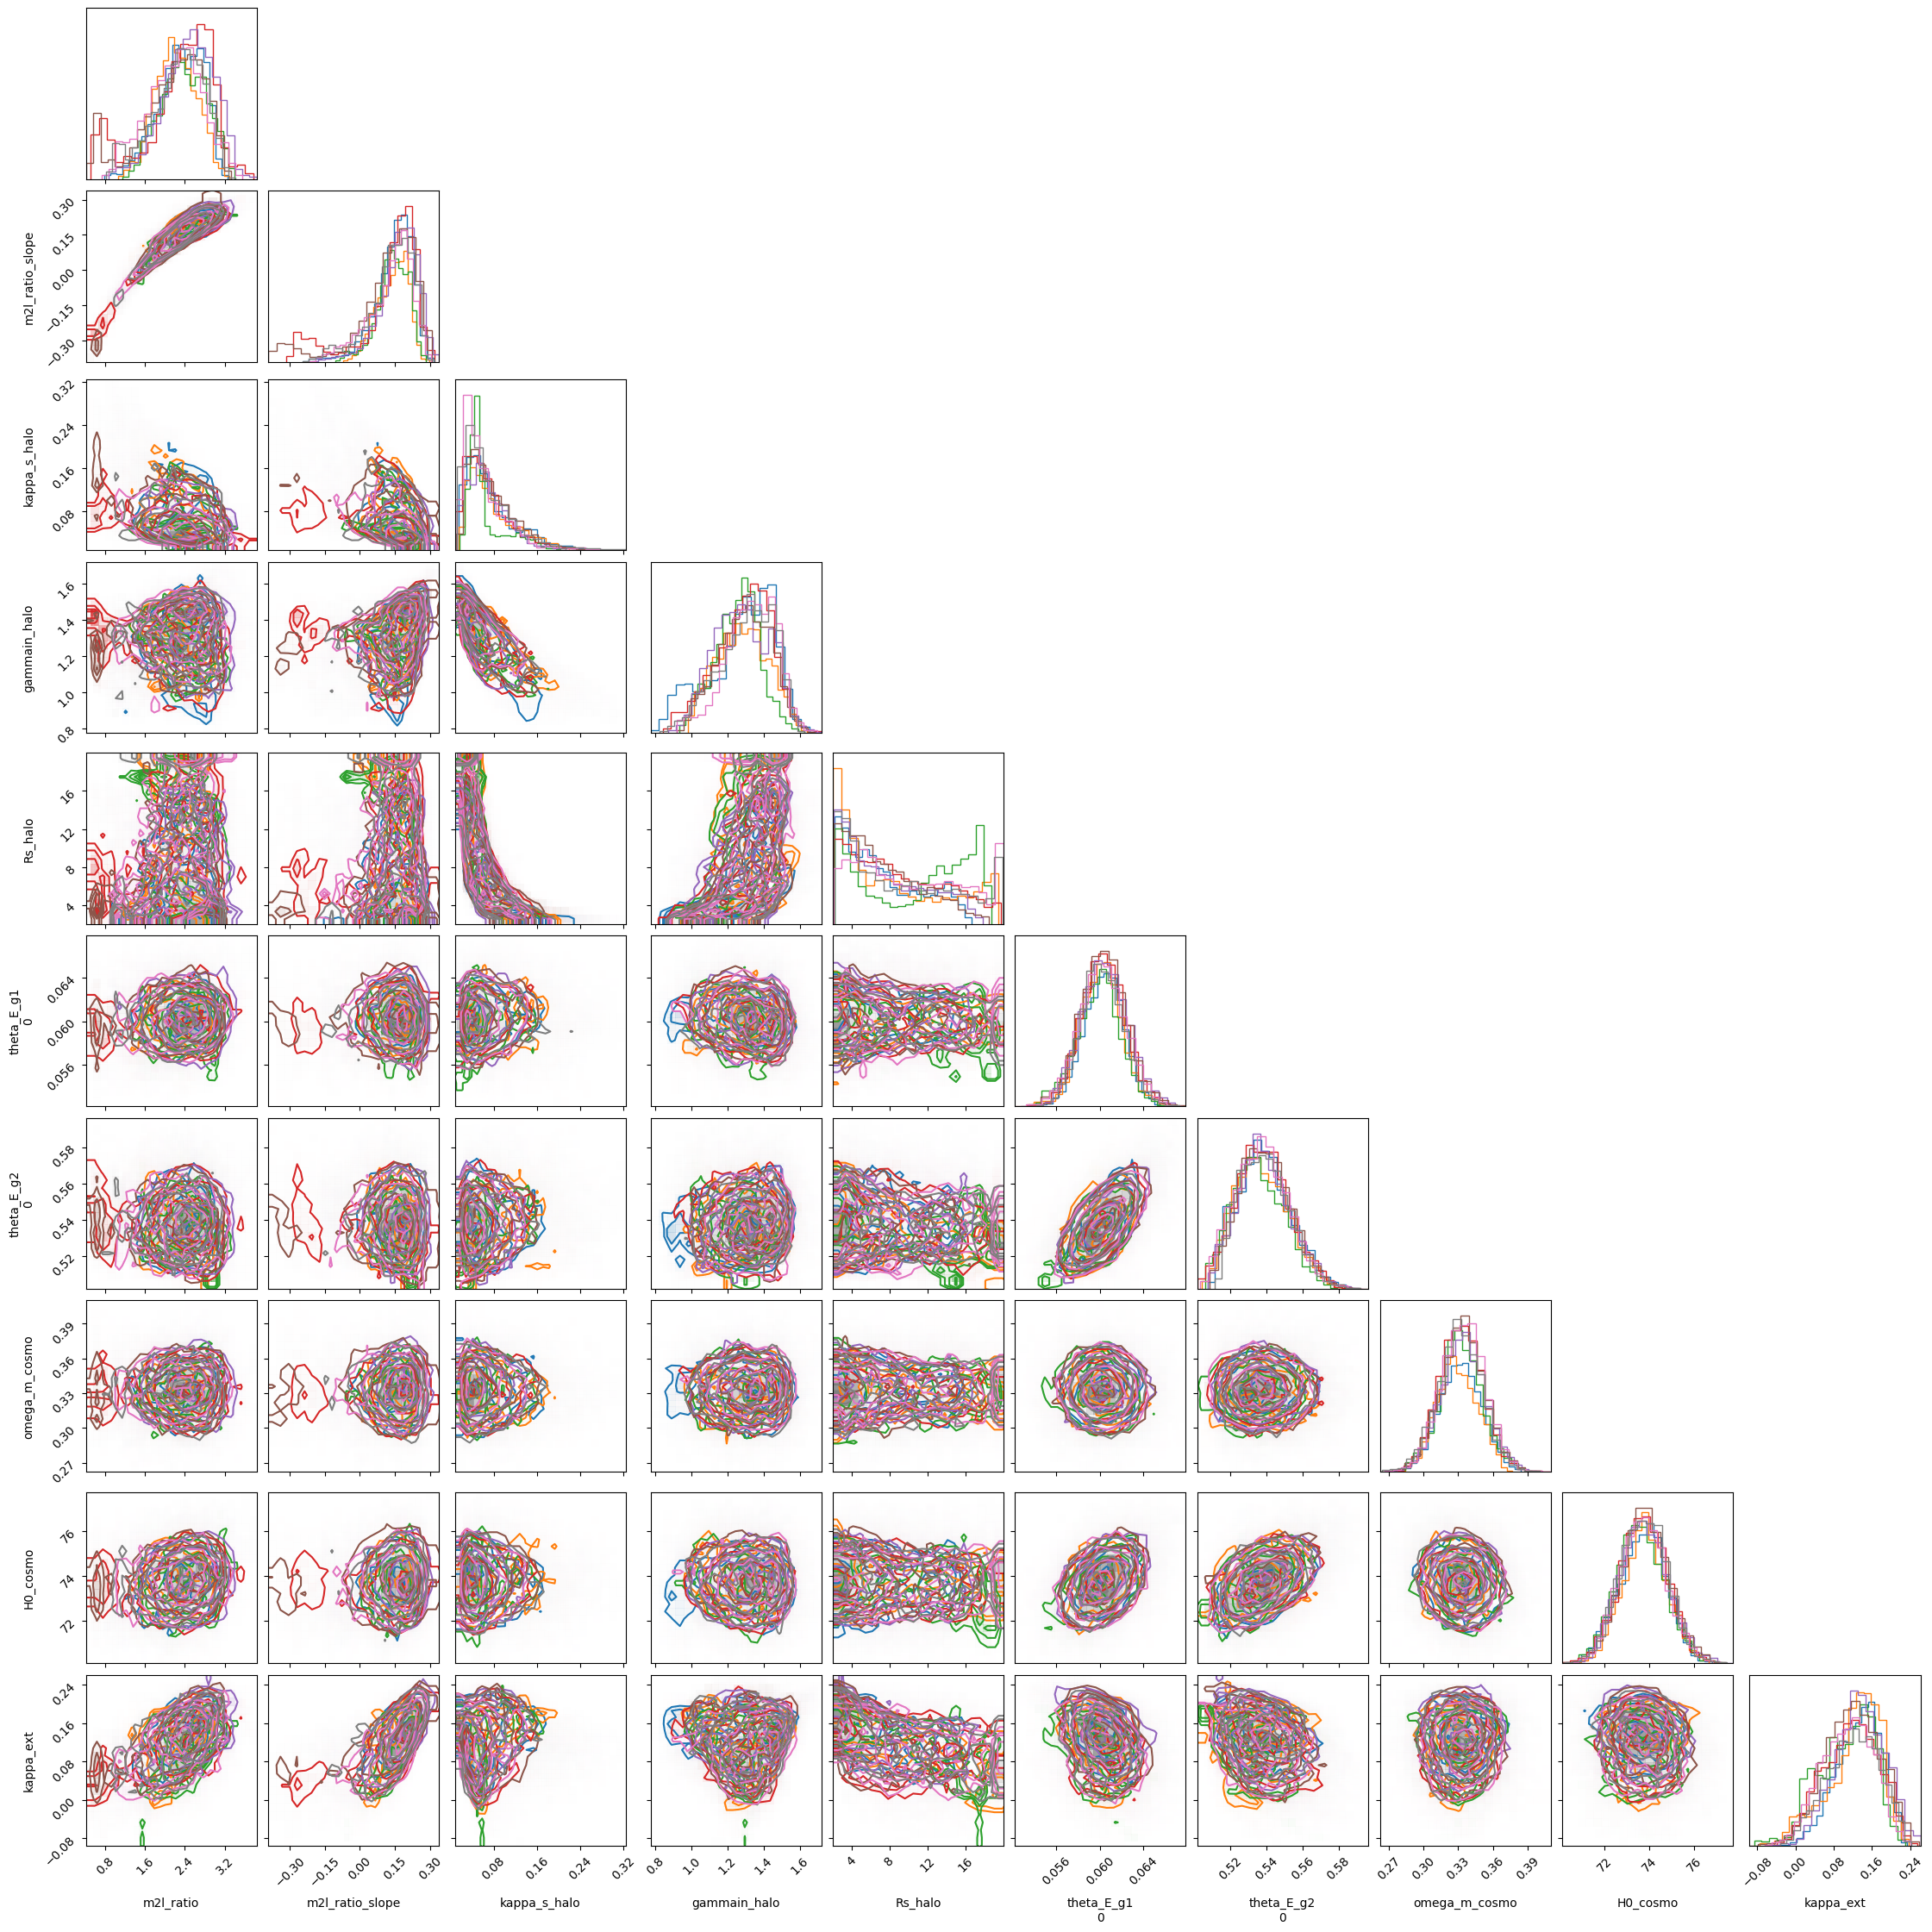

In [7]:
fig_corner = None
for chain_index in range(num_chains):
    fig_corner = corner.corner(
        diagnostic_post.isel(chain=chain_index),
        var_names=CORNER_VARS,
        color=f'C{chain_index}',
        fig=fig_corner,
        show_titles=False,
        plot_datapoints=False,
        fill_contours=False,
    )
plt.show()


In [8]:
with fits.open(RAW_DATA_PATH, memmap=True) as hdul_raw:
    raw_header = hdul_raw['SCI'].header if 'SCI' in hdul_raw else hdul_raw[0].header
    exposure_time = float(raw_header.get('EXPTIME', raw_header.get('TEXPTIME', raw_header.get('XPOSURE', 1.0))))
pix_scale = float(np.sqrt(raw_header['PIXAR_A2']))

data_bkg_sub = np.asarray(fits.getdata(DATA_BKG_SUB_PATH), dtype=float)
data_subtracted = np.asarray(fits.getdata(DATA_SUB_PATH), dtype=float)
lens_light = data_bkg_sub - data_subtracted
rms_file = np.asarray(fits.getdata(RMS_WITH_PSF_EXTRA_PATH), dtype=float)
mask_plot = np.asarray(fits.getdata(MASK_OUT_PATH), dtype=bool)
fixed_five_gaussians = np.load(FIXED_FIVE_GAUSS_PATH)

ny, nx = data_subtracted.shape
extent = [
    -nx * pix_scale / 2,
    nx * pix_scale / 2,
    -ny * pix_scale / 2,
    ny * pix_scale / 2,
]

pixel_grid = PixelGrid(
    nx=nx,
    ny=ny,
    ra_at_xy_0=-nx * pix_scale / 2 + pix_scale / 2,
    dec_at_xy_0=-ny * pix_scale / 2 + pix_scale / 2,
    transform_pix2angle=pix_scale * np.eye(2),
)

pixel_grid_shape = int(post['pixels_source_grid'].shape[-1])
source_grid_scale = 0.8
ss_factor = 2
conj_points = jnp.array([
    [1.20212170716053, -0.12271885209256231],
    [0.9053233071260114, 0.5277189685977776],
    [-1.0461673774453952, 1.0081083299749878],
    [-0.1255456241215261, -0.8965524340129204],
])

G1_MASS_CENTER = (1.556, 1.299)
G2_MASS_CENTER = (2.145, -3.326)
G3_MASS_CENTER = (4.243403, 6.185564)
G7_MASS_CENTER = (-7.284665, -10.319681)
SIS_G2_THETA_MEAN = 0.622
SIS_G3_THETA_MEAN = 0.088
SIS_G7_THETA_MEAN = 0.388

mass_model_step6 = MassModel([
    'MULTI_GAUSSIAN_ELLIPSE_KAPPA',
    'CUSPY_NFW_ELLIPSE_KAPPA',
    'SHEAR',
    'SIS',
    'SIS',
    'SIS',
    'SIS',
    'CONVERGENCE',
])
source_light_model = LightModel(
    ['PIXELATED'],
    pixel_adaptive_grid=True,
    pixel_interpol='fast_bilinear',
    kwargs_pixelated={'num_pixels': pixel_grid_shape},
)
point_source_model = PointSourceModel(
    ['IMAGE_POSITIONS'],
    mass_model=mass_model_step6,
    image_plane=pixel_grid,
)
psf_obj = PSF(psf_type='PIXEL', kernel_point_source=np.ones((3, 3), dtype=float) / 9.0)
noise = Noise(nx, ny, exposure_time=exposure_time)
lens_image_step6 = LensImageExtension(
    pixel_grid,
    psf_obj,
    noise_class=noise,
    lens_light_model_class=LightModel(['MULTI_GAUSSIAN_ELLIPSE'], {}),
    lens_mass_model_class=mass_model_step6,
    source_model_class=source_light_model,
    point_source_model_class=point_source_model,
    source_arc_mask=jnp.array(mask_plot),
    conjugate_points=conj_points,
    kwargs_numerics={'supersampling_factor': ss_factor},
    source_grid_scale=source_grid_scale,
)

print('data_bkg_sub shape =', data_bkg_sub.shape)
print('data_subtracted shape =', data_subtracted.shape)
print('lens_light shape =', lens_light.shape)
print('rms_file shape =', rms_file.shape)
print('mask_plot shape =', mask_plot.shape)
print('pix_scale =', pix_scale)
print('pixel_grid_shape =', pixel_grid_shape)


data_bkg_sub shape = (150, 150)
data_subtracted shape = (150, 150)
lens_light shape = (150, 150)
rms_file shape = (150, 150)
mask_plot shape = (150, 150)
pix_scale = 0.031224452218231436
pixel_grid_shape = 74


In [9]:
def chain_draw_median(name, chain_index):
    return np.asarray(
        post[name].isel(chain=chain_index).median(dim='draw').values,
        dtype=float,
    )


def all_draw_median(name):
    return np.asarray(post[name].median(dim=('chain', 'draw')).values, dtype=float)


def fixed_sis(theta_E, origin):
    return [{
        'theta_E': float(np.asarray(theta_E).reshape(-1)[0]),
        'center_x': float(origin[0]),
        'center_y': float(origin[1]),
    }]


def theta_E_scaled_from_g2(theta_E_g2, target_theta_mean):
    return float(np.asarray(theta_E_g2).reshape(-1)[0]) * target_theta_mean / SIS_G2_THETA_MEAN


def kwargs_lens_from_values(values):
    e_halo = np.asarray(values['e_halo'], dtype=float).reshape(2,)
    center_halo = np.asarray(values['center_halo'], dtype=float).reshape(2,)
    gamma_shear = np.asarray(values['gamma_sheer_halo'], dtype=float).reshape(2,)
    theta_E_g2 = float(np.asarray(values['theta_E_g2']).reshape(-1)[0])

    mass_from_light = [{
        'amp': np.asarray(values['mass_from_light_amp'], dtype=float),
        'sigma': np.asarray(fixed_five_gaussians['sigma'], dtype=float),
        'e1': np.asarray(fixed_five_gaussians['e1'], dtype=float),
        'e2': np.asarray(fixed_five_gaussians['e2'], dtype=float),
        'center_x': np.asarray(fixed_five_gaussians['center_x'], dtype=float),
        'center_y': np.asarray(fixed_five_gaussians['center_y'], dtype=float),
    }]
    gnfw_shear = [{
        'R_s': float(np.asarray(values['Rs_halo']).reshape(-1)[0]),
        'gamma': float(np.asarray(values['gammain_halo']).reshape(-1)[0]),
        'kappa_s': float(np.asarray(values['kappa_s_halo']).reshape(-1)[0]),
        'e1': float(e_halo[0]),
        'e2': float(e_halo[1]),
        'center_x': float(center_halo[0]),
        'center_y': float(center_halo[1]),
    }, {
        'gamma1': float(gamma_shear[0]),
        'gamma2': float(gamma_shear[1]),
        'ra_0': float(center_halo[0]),
        'dec_0': float(center_halo[1]),
    }]
    sis_mass = (
        fixed_sis(values['theta_E_g1'], G1_MASS_CENTER)
        + fixed_sis(theta_E_g2, G2_MASS_CENTER)
        + fixed_sis(theta_E_scaled_from_g2(theta_E_g2, SIS_G3_THETA_MEAN), G3_MASS_CENTER)
        + fixed_sis(theta_E_scaled_from_g2(theta_E_g2, SIS_G7_THETA_MEAN), G7_MASS_CENTER)
    )
    convergence = [{
        'kappa': float(np.asarray(values['kappa_ext']).reshape(-1)[0]),
        'ra_0': 0.0,
        'dec_0': 0.0,
    }]
    return mass_from_light + gnfw_shear + sis_mass + convergence


def kwargs_lens_for_chain(chain_index):
    return kwargs_lens_from_values({
        name: chain_draw_median(name, chain_index)
        for name in [
            'mass_from_light_amp',
            'kappa_s_halo',
            'gammain_halo',
            'e_halo',
            'Rs_halo',
            'center_halo',
            'gamma_sheer_halo',
            'theta_E_g1',
            'theta_E_g2',
            'kappa_ext',
        ]
    })


def source_plane_image_and_caustics(source_pixels, kwargs_lens):
    herc_dict = {
        'kwargs_lens': kwargs_lens,
        'kwargs_source': [{'pixels': np.asarray(source_pixels)}],
    }
    source_image, source_extent = pixelize_plane_single(
        lens_image_step6,
        herc_dict,
        pixel_grid_shape,
    )
    _critical_lines, caustics = model_util.critical_lines_caustics(
        lens_image_step6,
        kwargs_lens,
        supersampling=2,
    )
    return np.asarray(source_image), source_extent, caustics


def draw_source_panel(ax_source, source_pixels, kwargs_lens, title):
    source_image, source_extent, caustics = source_plane_image_and_caustics(source_pixels, kwargs_lens)
    ax_source.imshow(source_image, cmap='twilight', origin='lower', extent=source_extent)

    xs = [source_extent[0], source_extent[1]]
    ys = [source_extent[2], source_extent[3]]
    for curve_x, curve_y in caustics:
        curve_x = np.asarray(curve_x)
        curve_y = np.asarray(curve_y)
        ax_source.plot(curve_x, curve_y, color='black', linewidth=1.2, alpha=0.7, linestyle='dashed')
        finite = np.isfinite(curve_x) & np.isfinite(curve_y)
        xs.extend(curve_x[finite])
        ys.extend(curve_y[finite])

    xmin, xmax = np.nanmin(xs), np.nanmax(xs)
    ymin, ymax = np.nanmin(ys), np.nanmax(ys)
    xmid = 0.5 * (xmin + xmax)
    ymid = 0.5 * (ymin + ymax)
    half_width = 0.52 * max(xmax - xmin, ymax - ymin)
    ax_source.set_xlim(xmid - half_width, xmid + half_width)
    ax_source.set_ylim(ymid - half_width, ymid + half_width)
    ax_source.set_aspect('equal', adjustable='box')
    ax_source.set_title(title)


def plot_chain(chain_index):
    model_image = chain_draw_median('model_image', chain_index)
    source_pixels = chain_draw_median('pixels_source_grid', chain_index)
    psf_corrected = chain_draw_median('psf_kernel_corrected', chain_index)
    psf_corrected = np.clip(psf_corrected, 0.0, None)
    psf_corrected = psf_corrected / np.sum(psf_corrected)
    residual = (data_subtracted - model_image) / rms_file
    kwargs_lens = kwargs_lens_for_chain(chain_index)

    fig, ax = plt.subplots(2, 3, figsize=(10, 8), constrained_layout=False)
    # fig.subplots_adjust(
    #     left=0.03,
    #     right=0.98,
    #     bottom=0.04,
    #     top=0.90,
    #     wspace=0.08,
    #     hspace=0.08,
    # )


    ax[0, 0].imshow(
        np.ma.array(data_subtracted, mask=~mask_plot),
        norm='log',
        cmap='twilight',
        origin='lower',
        extent=extent,
        vmin=0.001,
    )
    ax[0, 0].set_title('Data (lens light subtracted)')

    ax[0, 1].imshow(
        np.ma.array(model_image, mask=~mask_plot),
        norm='log',
        cmap='twilight',
        origin='lower',
        extent=extent,
        vmin=0.001,
    )
    ax[0, 1].set_title('Lens model')

    im_res = ax[0, 2].imshow(
        np.ma.array(residual, mask=~mask_plot),
        cmap='bwr',
        vmin=-3,
        vmax=3,
        origin='lower',
        extent=extent,
    )
    ax[0, 2].set_title('Residual')
    draw_source_panel(ax[1, 0], source_pixels, kwargs_lens, 'Source')

    ax[1, 1].imshow(
        np.ma.array(lens_light, mask=~mask_plot),
        norm='log',
        cmap='twilight',
        origin='lower',
        extent=extent,
        vmin=0.001,
    )
    ax[1, 1].set_title('Lens light')

    eps = 1e-12
    vmax_psf = np.nanmax(psf_corrected)
    psf_norm = colors.LogNorm(vmin=max(vmax_psf * 1e-6, eps), vmax=max(vmax_psf, eps * 10))
    ax[1, 2].imshow(np.clip(psf_corrected, eps, None), cmap='viridis', norm=psf_norm, origin='lower')
    ax[1, 2].set_title('Corrected PSF')

    for axis in ax.ravel():
        axis.set_xticks([])
        axis.set_yticks([])
        axis.set_aspect('equal', adjustable='box')

    fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=0.88, wspace=0.02, hspace=0.10)

    # Manual colorbar above residual, after final subplot positions are fixed.
    bbox = ax[0, 2].get_position()
    cax = fig.add_axes([
        bbox.x0 + 0.08 * bbox.width,
        bbox.y1 + 0.055,
        0.84 * bbox.width,
        0.016,
    ])
    cbar = fig.colorbar(im_res, cax=cax, orientation='horizontal')
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')

    plt.show()

    return {
        'model_image': model_image,
        'source_image': source_pixels,
        'psf_corrected': psf_corrected,
        'residual': residual,
        'kwargs_lens': kwargs_lens,
    }


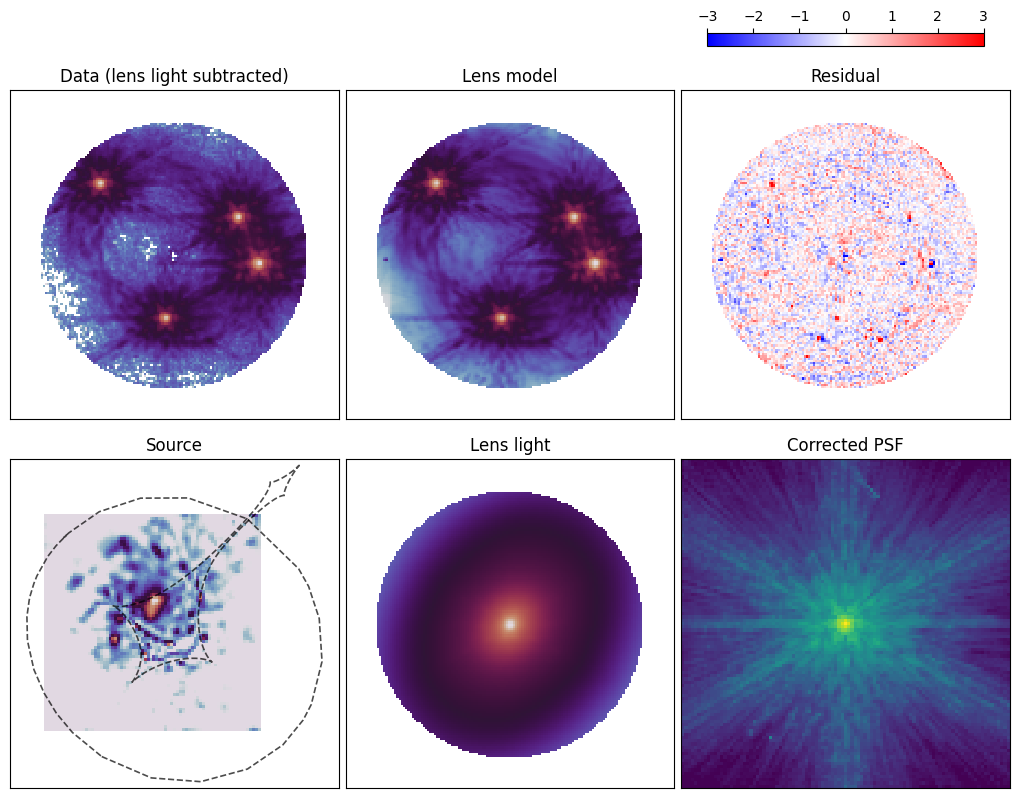

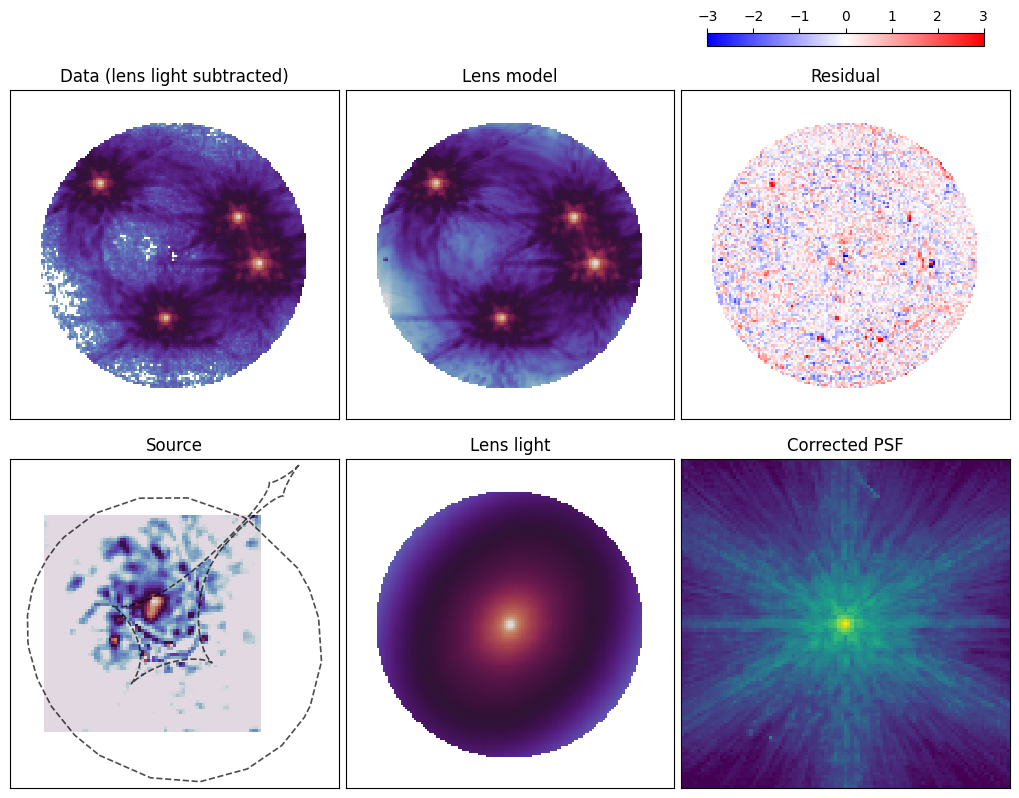

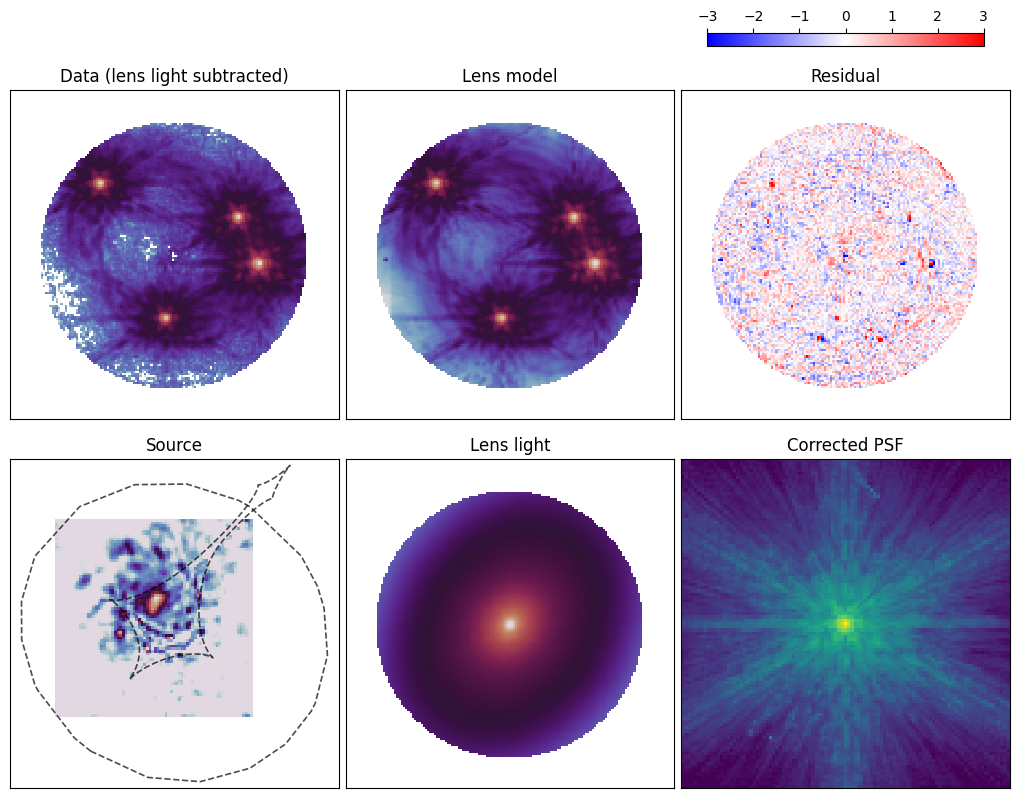

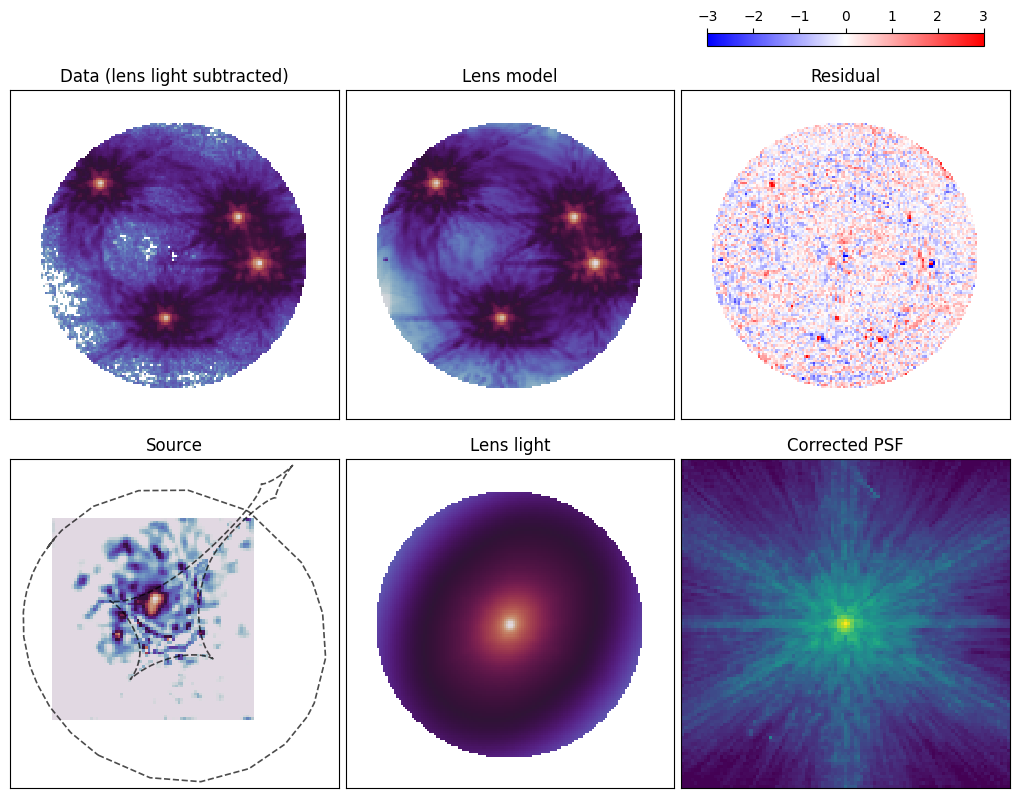

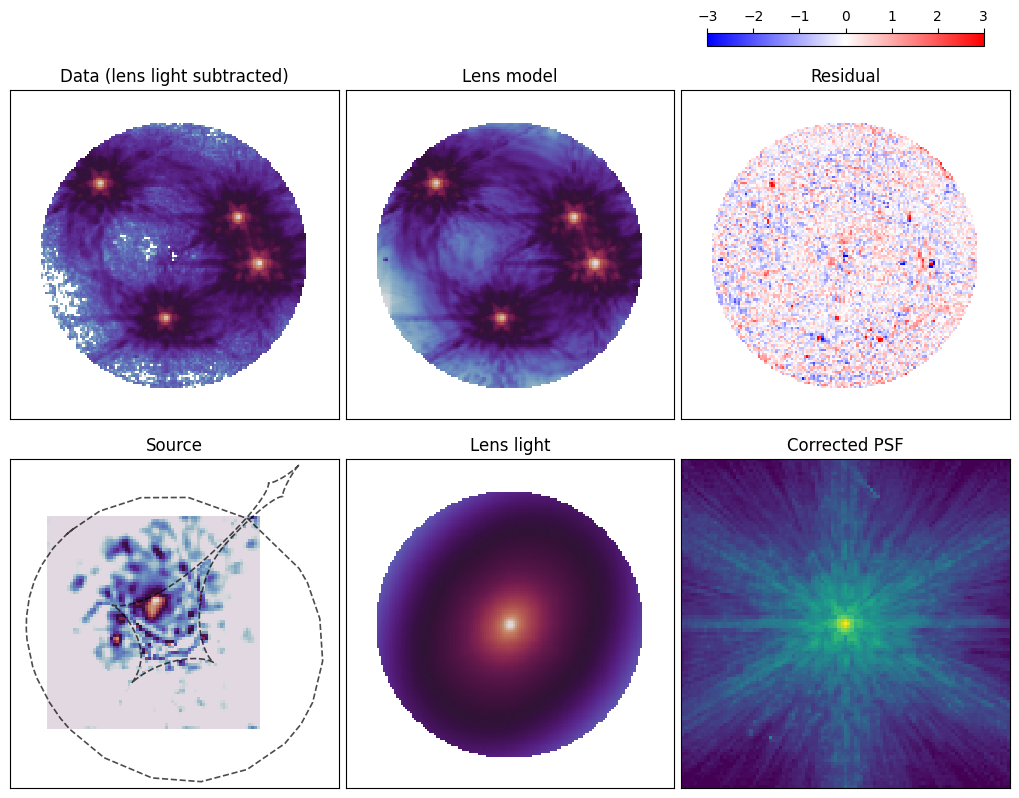

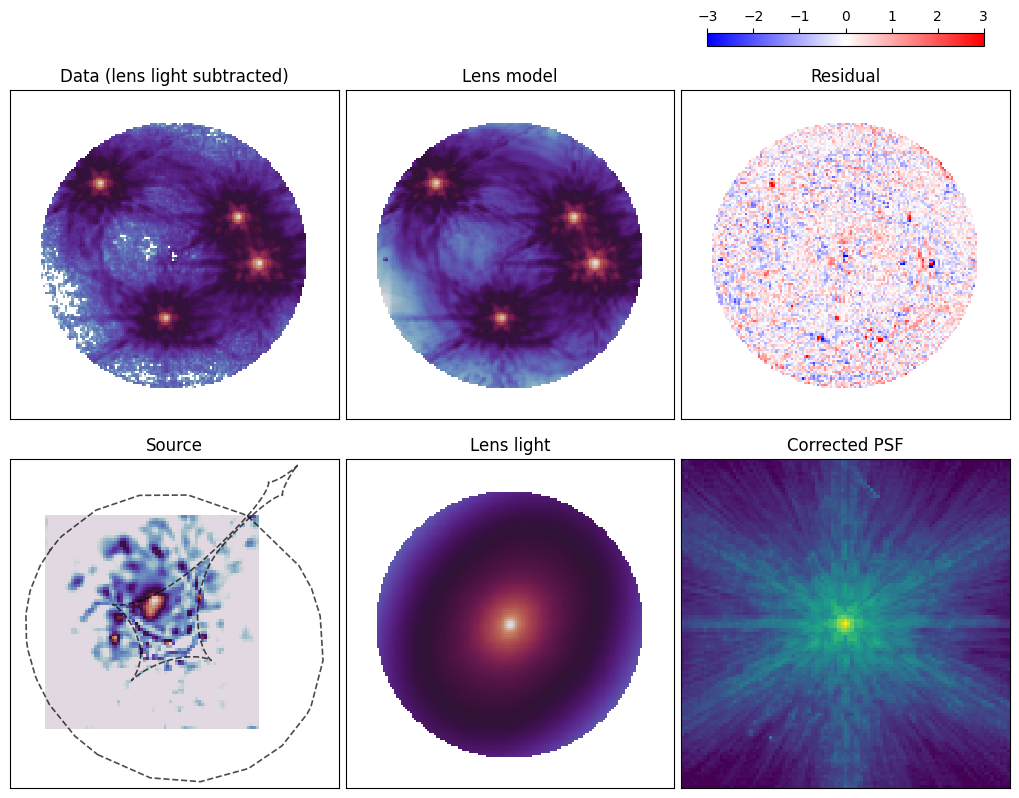

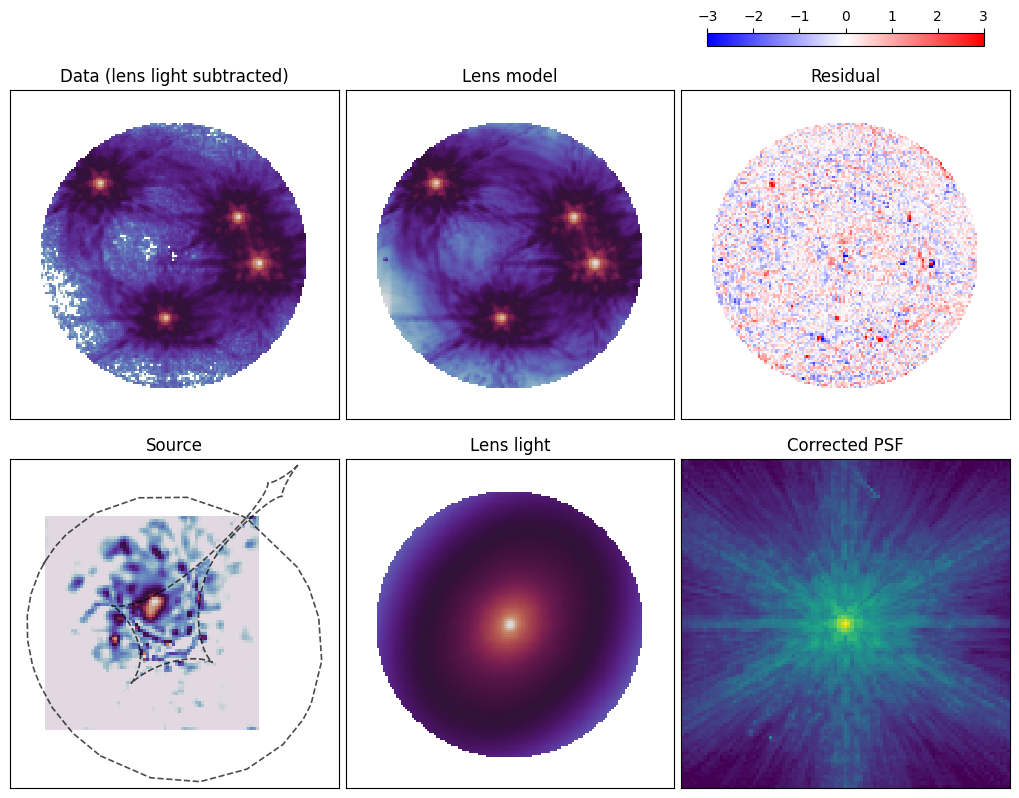

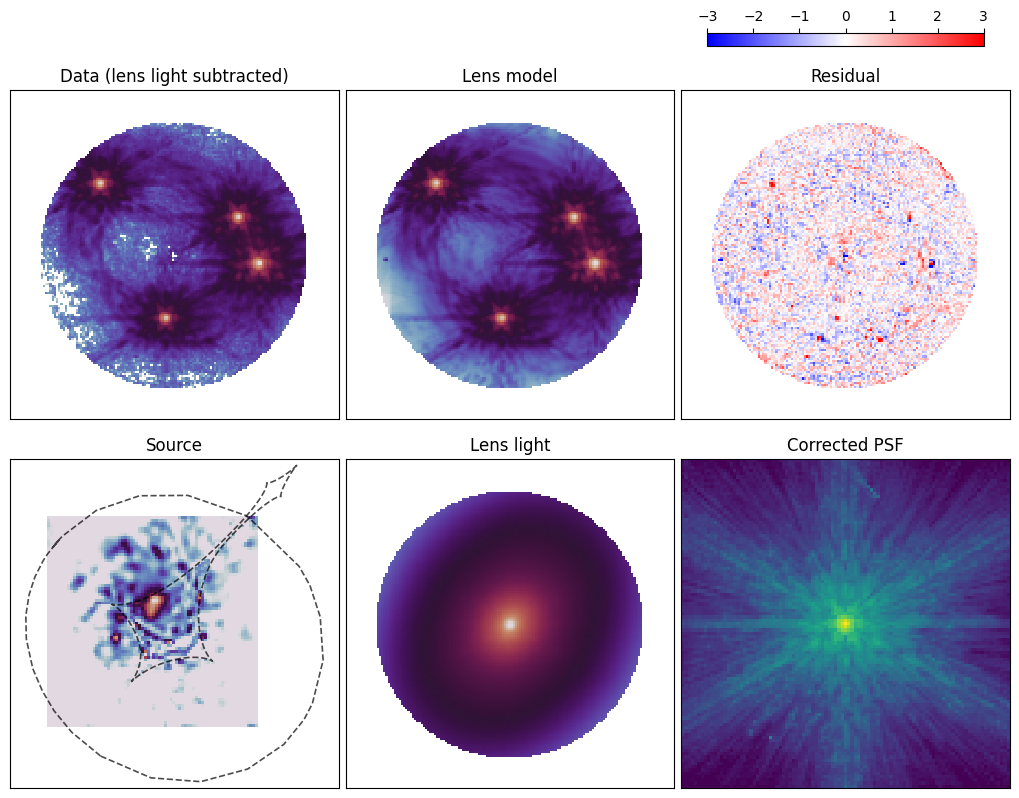

In [10]:
# Per-chain visualization, matching the Step_5_data_visullization style but using Step 6 deterministics.
chain_products = {}
for chain_index in range(num_chains):
    chain_products[chain_index] = plot_chain(chain_index)


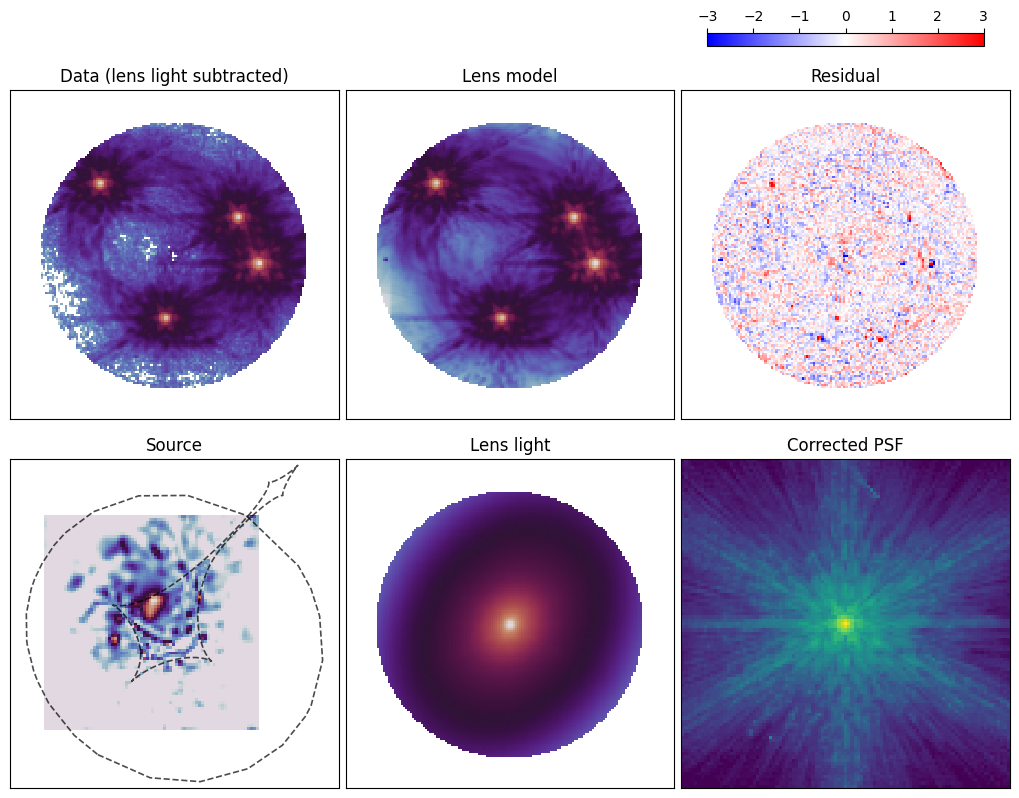

In [11]:
# Average visualization over all chains
model_image_avg = np.mean([chain_products[i]['model_image'] for i in range(num_chains)], axis=0)
source_image_avg = np.mean([chain_products[i]['source_image'] for i in range(num_chains)], axis=0)
psf_corrected_avg = np.mean([chain_products[i]['psf_corrected'] for i in range(num_chains)], axis=0)
psf_corrected_avg = np.clip(psf_corrected_avg, 0.0, None)
psf_corrected_avg = psf_corrected_avg / np.sum(psf_corrected_avg)
residual_avg = (data_subtracted - model_image_avg) / rms_file
kwargs_lens_avg = kwargs_lens_from_values({
    name: all_draw_median(name)
    for name in [
        'mass_from_light_amp',
        'kappa_s_halo',
        'gammain_halo',
        'e_halo',
        'Rs_halo',
        'center_halo',
        'gamma_sheer_halo',
        'theta_E_g1',
        'theta_E_g2',
        'kappa_ext',
    ]
})

fig, ax = plt.subplots(2, 3, figsize=(10, 8), constrained_layout=False)

ax[0, 0].imshow(np.ma.array(data_subtracted, mask=~mask_plot), norm='log', cmap='twilight', origin='lower', extent=extent, vmin=0.001)
ax[0, 0].set_title('Data (lens light subtracted)')

ax[0, 1].imshow(np.ma.array(model_image_avg, mask=~mask_plot), norm='log', cmap='twilight', origin='lower', extent=extent, vmin=0.001)
ax[0, 1].set_title('Lens model')

im_res = ax[0, 2].imshow(np.ma.array(residual_avg, mask=~mask_plot), cmap='bwr', vmin=-3, vmax=3, origin='lower', extent=extent)
ax[0, 2].set_title('Residual')
draw_source_panel(ax[1, 0], source_image_avg, kwargs_lens_avg, 'Source')

ax[1, 1].imshow(np.ma.array(lens_light, mask=~mask_plot), norm='log', cmap='twilight', origin='lower', extent=extent, vmin=0.001)
ax[1, 1].set_title('Lens light')

eps = 1e-12
vmax_psf = np.nanmax(psf_corrected_avg)
psf_norm = colors.LogNorm(vmin=max(vmax_psf * 1e-6, eps), vmax=max(vmax_psf, eps * 10))
ax[1, 2].imshow(np.clip(psf_corrected_avg, eps, None), cmap='viridis', norm=psf_norm, origin='lower')
ax[1, 2].set_title('Corrected PSF')

for axis in ax.ravel():
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_aspect('equal', adjustable='box')

fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=0.88, wspace=0.02, hspace=0.10)

# Manual colorbar above residual, after final subplot positions are fixed.
bbox = ax[0, 2].get_position()
cax = fig.add_axes([
    bbox.x0 + 0.08 * bbox.width,
    bbox.y1 + 0.055,
    0.84 * bbox.width,
    0.016,
])
cbar = fig.colorbar(im_res, cax=cax, orientation='horizontal')
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')

plt.show()



In [12]:
diagnostic_idata.to_netcdf("step6_SH0ES_idata.nc")

'step6_SH0ES_idata.nc'